# 📊 Notebook 01 — Yelp Dataset Exploration
**Root & Rise | DSN x BCT LLM Agent Challenge 2026**

This notebook covers end-to-end EDA of the Yelp Academic Dataset.
The goal is to understand the data well enough to design both:
- **Task A** — persona extraction and review generation
- **Task B** — recommendation retrieval and ranking

### What we explore:
1. Dataset loading and schema inspection
2. Review distribution analysis (ratings, length, sentiment)
3. User behaviour profiling (rating habits, activity patterns)
4. Business metadata analysis (categories, geography)
5. Persona signal extraction
6. Cold-start identification
7. Data splits for evaluation

---
## 0. Setup

In [1]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
from pathlib import Path
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Paths
ROOT = Path('..').resolve()
RAW_DIR = ROOT / 'data' / 'raw' / 'yelp'
PROCESSED_DIR = ROOT / 'data' / 'processed'
SAMPLE_DIR = ROOT / 'data' / 'sample'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
FIGSIZE = (12, 5)

print(f'ROOT: {ROOT}')
print(f'Raw data dir: {RAW_DIR}')
print(f'Raw dir exists: {RAW_DIR.exists()}')

ROOT: /home/gabe/root-and-rise
Raw data dir: /home/gabe/root-and-rise/data/raw/yelp
Raw dir exists: False


---
## 1. Load Dataset
The Yelp dataset is newline-delimited JSON (one object per line).
We load a configurable number of records for quick iteration.
Change `MAX_REVIEWS` to `None` to load the full dataset.

In [2]:
MAX_REVIEWS = 200_000   # Set to None for full dataset (~7M reviews)
MAX_USERS   = 100_000
MAX_BIZS    = 150_000

def load_jsonl(path: Path, max_rows=None, desc='Loading') -> pd.DataFrame:
    """Load a newline-delimited JSON file into a DataFrame."""
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(tqdm(f, desc=desc)):
            if max_rows and i >= max_rows:
                break
            records.append(json.loads(line))
    return pd.DataFrame(records)


# --- Reviews ---
review_path = RAW_DIR / 'yelp_academic_dataset_review.json'
if review_path.exists():
    df_reviews = load_jsonl(review_path, MAX_REVIEWS, desc='Reviews')
    print(f'\nReviews loaded: {len(df_reviews):,}')
    print(df_reviews.dtypes)
else:
    print('⚠️  Review file not found. Using synthetic sample for demo.')
    # --- Synthetic demo data (use when Yelp files not yet downloaded) ---
    import random, string
    random.seed(42)
    np.random.seed(42)

    N_USERS = 500
    N_BIZS = 200
    N_REVIEWS = 5000

    user_ids  = ['user_' + ''.join(random.choices(string.ascii_lowercase, k=8)) for _ in range(N_USERS)]
    biz_ids   = ['biz_'  + ''.join(random.choices(string.ascii_lowercase, k=8)) for _ in range(N_BIZS)]
    categories_pool = ['Restaurants','Fast Food','Bars','Coffee & Tea','Nightlife',
                       'Burgers','Pizza','Sushi','Nigerian','Chinese','Ice Cream',
                       'Grocery','Health & Medical','Beauty & Spas','Shopping']

    sample_texts = [
        "The jollof rice was on point, no lie. Spicy just the way I like it, service was quick.",
        "Honestly expected more. The suya was dry and the customer service left plenty to be desired.",
        "Very average experience. Nothing to write home about but nothing terrible either.",
        "This place is a hidden gem! The pepper soup warmed my soul. Will definitely be back.",
        "Overpriced for what you get. The ambiance was nice though, I'll give them that.",
        "Absolutely fantastic! Best pounded yam in the entire mainland, period.",
        "The food came cold and the waiter had an attitude. Not coming back.",
        "Decent spot. Good for a quick bite but nothing extraordinary.",
        "Five stars, no question. The egusi soup alone is worth the trip from the island.",
        "I've had better. The place was noisy and my order was wrong twice.",
    ]

    # Simulate users with different rating biases
    user_biases = {uid: np.random.choice(['harsh', 'balanced', 'generous'], p=[0.2, 0.5, 0.3])
                   for uid in user_ids}
    def gen_stars(bias):
        if bias == 'harsh':     return np.random.choice([1,2,3,4,5], p=[0.25,0.30,0.25,0.15,0.05])
        elif bias == 'generous': return np.random.choice([1,2,3,4,5], p=[0.02,0.05,0.13,0.35,0.45])
        else:                    return np.random.choice([1,2,3,4,5], p=[0.05,0.10,0.25,0.35,0.25])

    biz_cats = {bid: random.sample(categories_pool, random.randint(1,3)) for bid in biz_ids}
    import datetime
    base_date = datetime.date(2018, 1, 1)

    rows = []
    for _ in range(N_REVIEWS):
        uid = random.choice(user_ids)
        bid = random.choice(biz_ids)
        stars = gen_stars(user_biases[uid])
        date  = base_date + datetime.timedelta(days=random.randint(0, 2000))
        text  = random.choice(sample_texts)
        rows.append({'review_id': 'r'+str(_), 'user_id': uid, 'business_id': bid,
                     'stars': stars, 'text': text, 'date': str(date),
                     'useful': random.randint(0,5), 'funny': random.randint(0,3),
                     'cool': random.randint(0,3)})
    df_reviews = pd.DataFrame(rows)

    biz_rows = [{'business_id': bid, 'name': f'Business_{i}',
                 'categories': ', '.join(biz_cats[bid]),
                 'stars': round(np.random.uniform(2.5, 5.0), 1),
                 'review_count': random.randint(10, 500),
                 'city': random.choice(['Lagos', 'Abuja', 'Port Harcourt', 'Ibadan', 'Enugu']),
                 'state': 'NG'}
                for i, bid in enumerate(biz_ids)]
    df_business = pd.DataFrame(biz_rows)

    user_rows = [{'user_id': uid, 'name': f'User_{i}',
                  'review_count': random.randint(1, 200),
                  'average_stars': round(np.random.uniform(1.5, 5.0), 2),
                  'yelping_since': f'{random.randint(2010,2023)}-01-01'}
                 for i, uid in enumerate(user_ids)]
    df_users = pd.DataFrame(user_rows)

    print(f'Synthetic data generated: {len(df_reviews):,} reviews, {N_USERS} users, {N_BIZS} businesses')

print(df_reviews.head())

⚠️  Review file not found. Using synthetic sample for demo.
Synthetic data generated: 5,000 reviews, 500 users, 200 businesses
  review_id        user_id   business_id  stars  \
0        r0  user_cfesssgh  biz_pgoqovbd      5   
1        r1  user_umttlyoq  biz_scmrdtzz      4   
2        r2  user_btmqxepq  biz_donqmeps      4   
3        r3  user_kdjtmwhs  biz_utyllpad      5   
4        r4  user_ykluscky  biz_sgjpbyfm      5   

                                                text        date  useful  \
0  The jollof rice was on point, no lie. Spicy ju...  2019-04-05       0   
1  Decent spot. Good for a quick bite but nothing...  2022-09-05       0   
2  This place is a hidden gem! The pepper soup wa...  2023-02-01       0   
3  Absolutely fantastic! Best pounded yam in the ...  2021-05-11       4   
4  Decent spot. Good for a quick bite but nothing...  2021-07-10       5   

   funny  cool  
0      1     2  
1      2     3  
2      0     2  
3      3     3  
4      0     2  


In [3]:
# --- Businesses ---
biz_path = RAW_DIR / 'yelp_academic_dataset_business.json'
if biz_path.exists():
    df_business = load_jsonl(biz_path, MAX_BIZS, desc='Businesses')
    print(f'Businesses: {len(df_business):,}')

# --- Users ---
user_path = RAW_DIR / 'yelp_academic_dataset_user.json'
if user_path.exists():
    df_users = load_jsonl(user_path, MAX_USERS, desc='Users')
    print(f'Users: {len(df_users):,}')

---
## 2. Review Distribution Analysis

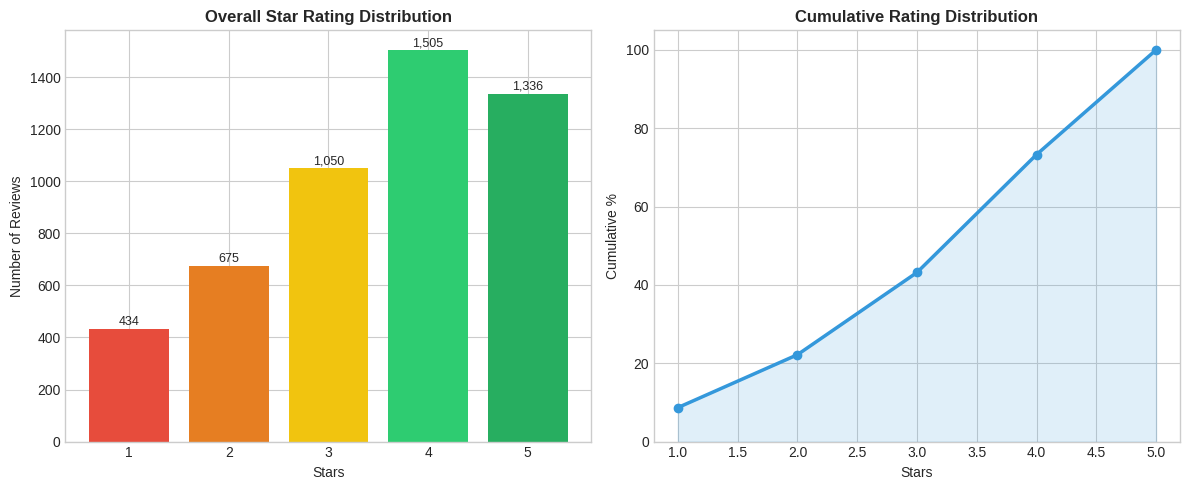

Mean rating: 3.527
Median rating: 4.0
Std: 1.255

% of 5-star reviews: 26.7%
% of 1-star reviews: 8.7%


In [4]:
# --- 2.1  Star Rating Distribution ---
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

star_counts = df_reviews['stars'].value_counts().sort_index()
axes[0].bar(star_counts.index, star_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[0].set_title('Overall Star Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Number of Reviews')
for i, v in zip(star_counts.index, star_counts.values):
    axes[0].text(i, v + max(star_counts)*0.01, f'{v:,}', ha='center', fontsize=9)

# Cumulative distribution
star_pct = (star_counts / star_counts.sum() * 100).cumsum()
axes[1].plot(star_pct.index, star_pct.values, marker='o', linewidth=2.5, color='#3498db')
axes[1].fill_between(star_pct.index, star_pct.values, alpha=0.15, color='#3498db')
axes[1].set_title('Cumulative Rating Distribution', fontweight='bold')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Cumulative %')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean rating: {df_reviews['stars'].mean():.3f}")
print(f"Median rating: {df_reviews['stars'].median():.1f}")
print(f"Std: {df_reviews['stars'].std():.3f}")
print(f"\n% of 5-star reviews: {(df_reviews['stars']==5).mean()*100:.1f}%")
print(f"% of 1-star reviews: {(df_reviews['stars']==1).mean()*100:.1f}%")

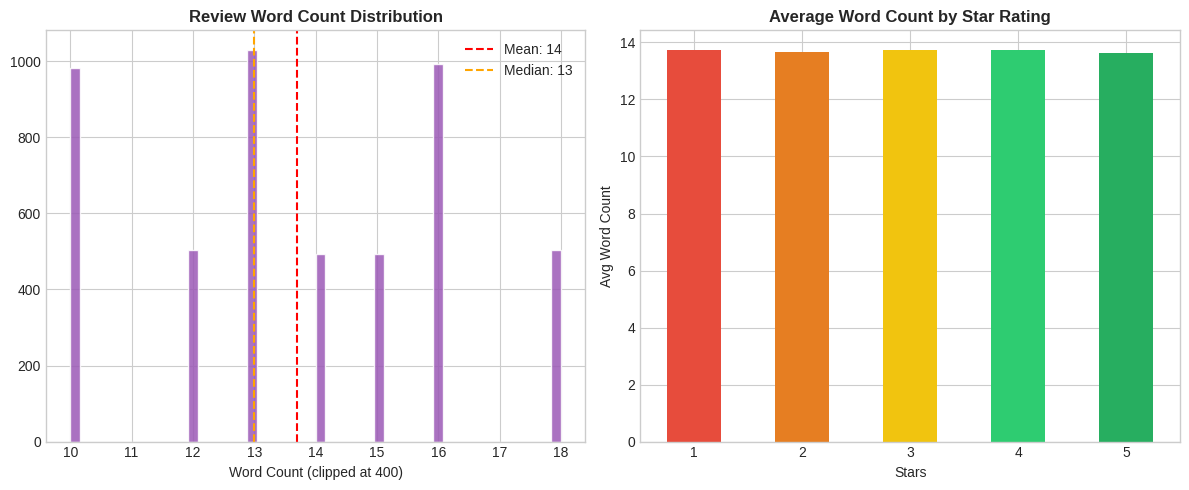

Word count stats:
count    5000.0
mean       13.7
std         2.5
min        10.0
25%        12.0
50%        13.0
75%        16.0
max        18.0
Name: word_count, dtype: float64


In [5]:
# --- 2.2  Review Length Analysis ---
df_reviews['word_count'] = df_reviews['text'].fillna('').apply(lambda x: len(x.split()))
df_reviews['char_count'] = df_reviews['text'].fillna('').apply(len)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Word count histogram
wc_clip = df_reviews['word_count'].clip(upper=400)
axes[0].hist(wc_clip, bins=50, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].axvline(df_reviews['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df_reviews["word_count"].mean():.0f}')
axes[0].axvline(df_reviews['word_count'].median(), color='orange', linestyle='--', label=f'Median: {df_reviews["word_count"].median():.0f}')
axes[0].set_title('Review Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Word Count (clipped at 400)')
axes[0].legend()

# Word count by star rating
df_reviews.groupby('stars')['word_count'].mean().plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
)
axes[1].set_title('Average Word Count by Star Rating', fontweight='bold')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Avg Word Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Word count stats:')
print(df_reviews['word_count'].describe().round(1))

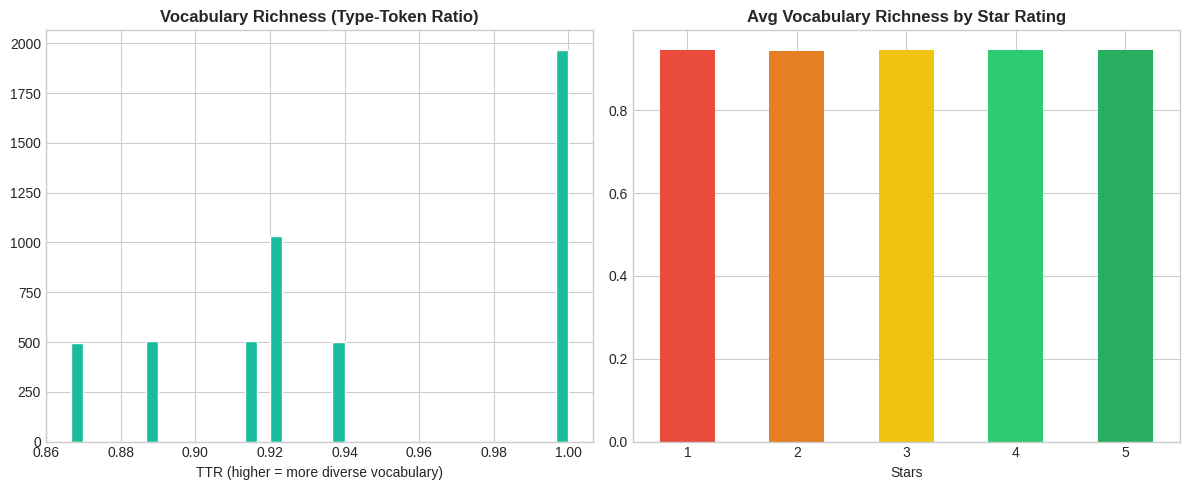

In [6]:
# --- 2.3  Review Text Quality Signals ---
# Type-Token Ratio (vocabulary richness) — sampled for speed
def type_token_ratio(text: str) -> float:
    tokens = text.lower().split()
    if not tokens:
        return 0.0
    return len(set(tokens)) / len(tokens)

sample_reviews = df_reviews.sample(min(5000, len(df_reviews)), random_state=42).copy()
sample_reviews['ttr'] = sample_reviews['text'].fillna('').apply(type_token_ratio)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].hist(sample_reviews['ttr'], bins=40, color='#1abc9c', edgecolor='white')
axes[0].set_title('Vocabulary Richness (Type-Token Ratio)', fontweight='bold')
axes[0].set_xlabel('TTR (higher = more diverse vocabulary)')

sample_reviews.groupby('stars')['ttr'].mean().plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
)
axes[1].set_title('Avg Vocabulary Richness by Star Rating', fontweight='bold')
axes[1].set_xlabel('Stars')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 3. User Behaviour Profiling
Key question: **How heterogeneous are users?**
If users are highly varied, persona modeling will be very valuable.

In [7]:
# --- 3.1  Per-User Statistics ---
user_stats = df_reviews.groupby('user_id').agg(
    n_reviews   = ('review_id', 'count'),
    avg_stars   = ('stars', 'mean'),
    std_stars   = ('stars', 'std'),
    avg_wc      = ('word_count', 'mean'),
).reset_index()

user_stats['std_stars'] = user_stats['std_stars'].fillna(0)
user_stats['rating_bias'] = pd.cut(
    user_stats['avg_stars'],
    bins=[0, 3.0, 4.0, 5.01],
    labels=['harsh', 'balanced', 'generous']
)

print(f'Total unique users: {len(user_stats):,}')
print(f'\nReviews per user:')
print(user_stats['n_reviews'].describe().round(1))
print(f'\nRating bias breakdown:')
print(user_stats['rating_bias'].value_counts(normalize=True).mul(100).round(1))

Total unique users: 499

Reviews per user:
count    499.0
mean      10.0
std        3.1
min        2.0
25%        8.0
50%       10.0
75%       12.0
max       23.0
Name: n_reviews, dtype: float64

Rating bias breakdown:
rating_bias
balanced    49.5
generous    25.5
harsh       25.1
Name: proportion, dtype: float64


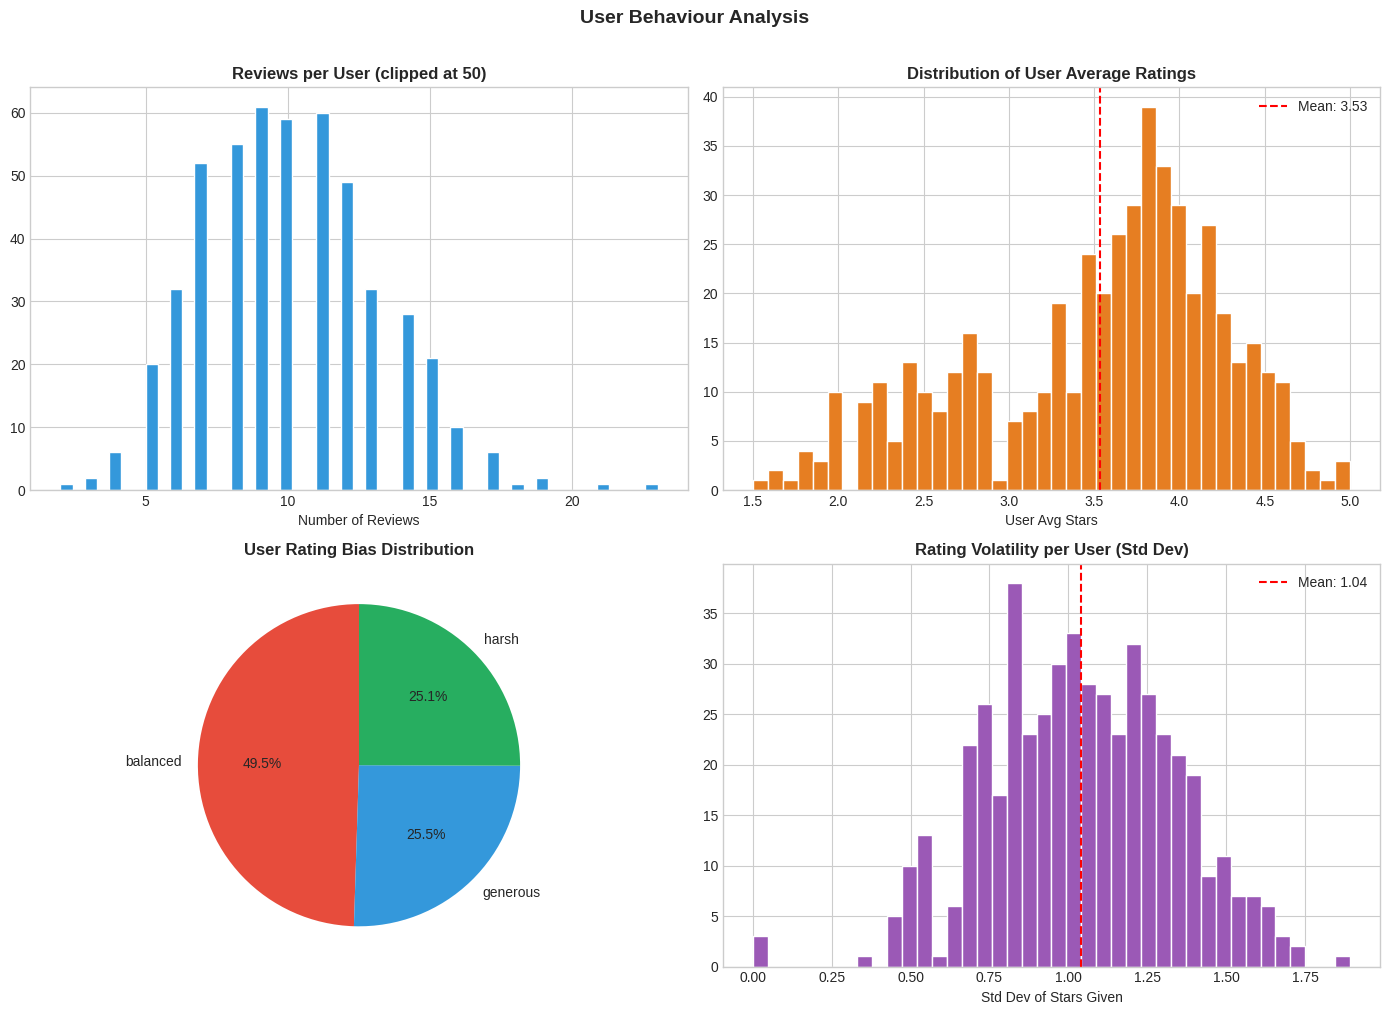

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Reviews per user (log scale)
axes[0,0].hist(user_stats['n_reviews'].clip(upper=50), bins=49,
               color='#3498db', edgecolor='white')
axes[0,0].set_title('Reviews per User (clipped at 50)', fontweight='bold')
axes[0,0].set_xlabel('Number of Reviews')

# Avg stars per user
axes[0,1].hist(user_stats['avg_stars'], bins=40, color='#e67e22', edgecolor='white')
axes[0,1].axvline(user_stats['avg_stars'].mean(), color='red', linestyle='--',
                   label=f'Mean: {user_stats["avg_stars"].mean():.2f}')
axes[0,1].set_title('Distribution of User Average Ratings', fontweight='bold')
axes[0,1].set_xlabel('User Avg Stars')
axes[0,1].legend()

# Rating bias pie
bias_counts = user_stats['rating_bias'].value_counts()
axes[1,0].pie(bias_counts.values, labels=bias_counts.index,
              autopct='%1.1f%%', colors=['#e74c3c','#3498db','#27ae60'],
              startangle=90)
axes[1,0].set_title('User Rating Bias Distribution', fontweight='bold')

# Std dev of ratings (rater volatility)
axes[1,1].hist(user_stats['std_stars'], bins=40, color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Rating Volatility per User (Std Dev)', fontweight='bold')
axes[1,1].set_xlabel('Std Dev of Stars Given')
axes[1,1].axvline(user_stats['std_stars'].mean(), color='red', linestyle='--',
                   label=f'Mean: {user_stats["std_stars"].mean():.2f}')
axes[1,1].legend()

plt.suptitle('User Behaviour Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'user_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

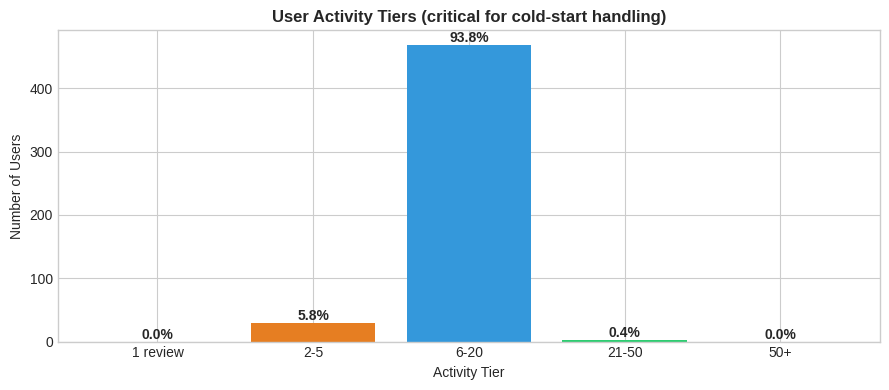


🔑 Cold-start users (≤5 reviews): 5.8% of all users
   → This is the population Task B cold-start handling must serve.


In [9]:
# --- 3.2  Power Users vs Casual Users ---
# This is important for cold-start analysis in Task B
bins = [0, 1, 5, 20, 50, float('inf')]
labels = ['1 review', '2-5', '6-20', '21-50', '50+']
user_stats['activity_tier'] = pd.cut(user_stats['n_reviews'], bins=bins, labels=labels)

tier_counts = user_stats['activity_tier'].value_counts().sort_index()
tier_pct = (tier_counts / len(user_stats) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=['#e74c3c','#e67e22','#3498db','#2ecc71','#9b59b6'])
for bar, pct in zip(bars, tier_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(tier_counts)*0.01,
            f'{pct}%', ha='center', fontweight='bold')
ax.set_title('User Activity Tiers (critical for cold-start handling)', fontweight='bold')
ax.set_xlabel('Activity Tier')
ax.set_ylabel('Number of Users')
plt.tight_layout()
plt.show()

cold_start_pct = (user_stats['n_reviews'] <= 5).mean() * 100
print(f'\n🔑 Cold-start users (≤5 reviews): {cold_start_pct:.1f}% of all users')
print('   → This is the population Task B cold-start handling must serve.')

---
## 4. Business Metadata Analysis

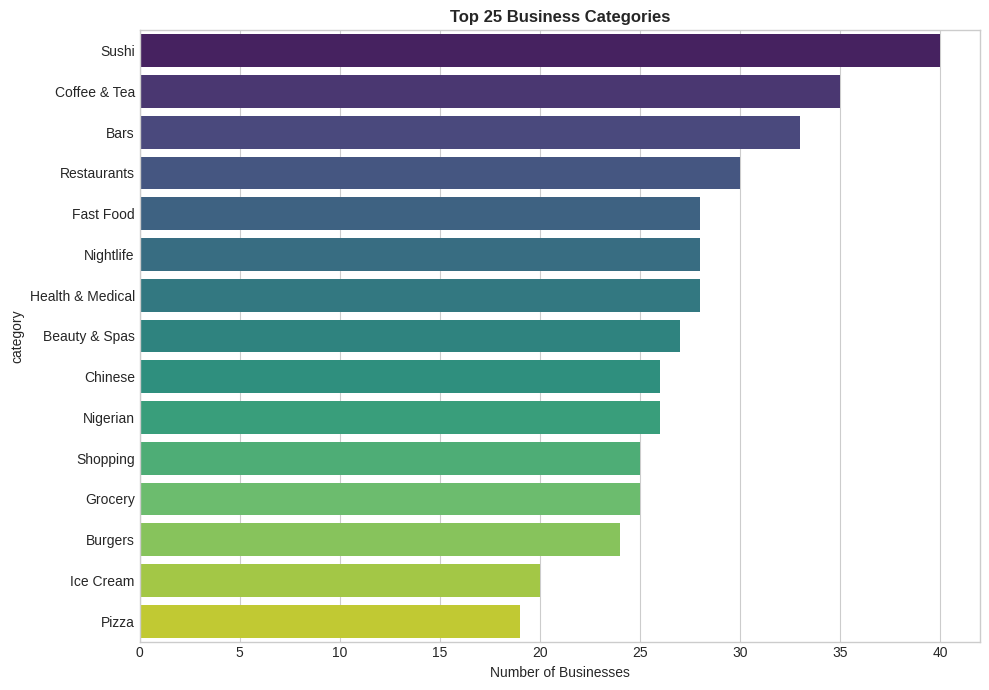

Total unique categories: 15


In [10]:
# --- 4.1  Category Distribution ---
# Parse categories (stored as comma-separated string in Yelp data)
if 'categories' in df_business.columns:
    all_cats = []
    for cats in df_business['categories'].dropna():
        all_cats.extend([c.strip() for c in cats.split(',')])
    cat_counts = Counter(all_cats)
    top_cats = pd.DataFrame(cat_counts.most_common(25),
                             columns=['category', 'count'])

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(data=top_cats, y='category', x='count', ax=ax,
                palette='viridis')
    ax.set_title('Top 25 Business Categories', fontweight='bold')
    ax.set_xlabel('Number of Businesses')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'top_categories.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Total unique categories: {len(cat_counts):,}')

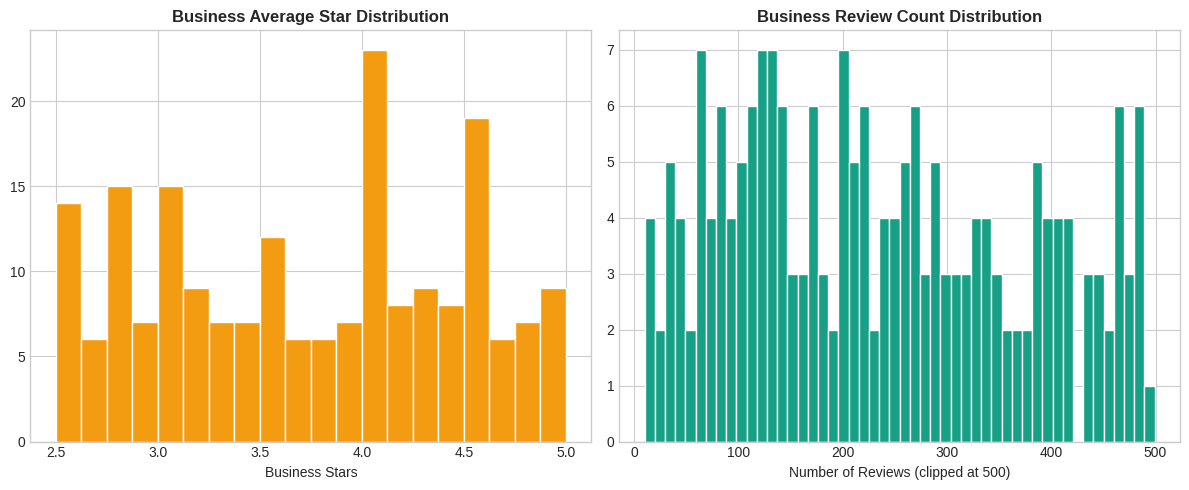

In [11]:
# --- 4.2  Business Star Distribution ---
if 'stars' in df_business.columns:
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
    df_business['stars'].hist(bins=20, ax=axes[0], color='#f39c12', edgecolor='white')
    axes[0].set_title('Business Average Star Distribution', fontweight='bold')
    axes[0].set_xlabel('Business Stars')

    if 'review_count' in df_business.columns:
        df_business['review_count'].clip(upper=500).hist(
            bins=50, ax=axes[1], color='#16a085', edgecolor='white')
        axes[1].set_title('Business Review Count Distribution', fontweight='bold')
        axes[1].set_xlabel('Number of Reviews (clipped at 500)')
    plt.tight_layout()
    plt.show()

---
## 5. Persona Signal Extraction
Here we identify the features that will form our `UserPersona` object.

In [12]:
# --- 5.1  Merge reviews with business categories ---
if 'categories' in df_business.columns:
    df_merged = df_reviews.merge(
        df_business[['business_id', 'name', 'categories', 'stars']].rename(
            columns={'stars': 'biz_stars', 'name': 'biz_name'}),
        on='business_id', how='left'
    )
else:
    df_merged = df_reviews.copy()
    df_merged['biz_name'] = 'Unknown'
    df_merged['categories'] = ''

print(f'Merged dataset: {len(df_merged):,} rows')
df_merged.head(2)

Merged dataset: 5,000 rows


,review_id,user_id,business_id,stars,text,date,useful,funny,cool,word_count,char_count,biz_name,categories,biz_stars
0,r0,user_cfesssgh,biz_pgoqovbd,5,"The jollof rice was on point, no lie. Spicy ju...",2019-04-05,0,1,2,18,86,Business_118,Nigerian,3.9
1,r1,user_umttlyoq,biz_scmrdtzz,4,Decent spot. Good for a quick bite but nothing...,2022-09-05,0,2,3,10,61,Business_163,"Beauty & Spas, Coffee & Tea, Sushi",3.9


In [13]:
# --- 5.2  Build rich per-user persona features ---
def extract_top_categories(group, top_n=5):
    all_cats = []
    for cats in group['categories'].dropna():
        all_cats.extend([c.strip() for c in str(cats).split(',') if c.strip()])
    return [cat for cat, _ in Counter(all_cats).most_common(top_n)]

def writing_style_label(avg_wc):
    if avg_wc < 50:  return 'concise'
    if avg_wc < 100: return 'neutral'
    if avg_wc < 180: return 'detailed'
    return 'verbose'

# Compute per-user aggregations
user_persona_features = []
for uid, group in tqdm(df_merged.groupby('user_id'), desc='Building personas'):
    stars_arr = group['stars'].values
    wcs = group['word_count'].values
    avg_s = float(np.mean(stars_arr))
    
    feature = {
        'user_id':         uid,
        'n_reviews':       len(group),
        'avg_stars':       round(avg_s, 2),
        'std_stars':       round(float(np.std(stars_arr)), 2),
        'star_1_pct':      round((stars_arr == 1).mean() * 100, 1),
        'star_5_pct':      round((stars_arr == 5).mean() * 100, 1),
        'avg_word_count':  round(float(np.mean(wcs)), 1),
        'writing_style':   writing_style_label(float(np.mean(wcs))),
        'rating_bias':     'harsh' if avg_s < 3.0 else ('generous' if avg_s > 4.0 else 'balanced'),
        'top_categories':  extract_top_categories(group),
        'useful_total':    int(group['useful'].sum()) if 'useful' in group else 0,
    }
    user_persona_features.append(feature)

df_personas = pd.DataFrame(user_persona_features)
print(f'\nPersonas extracted: {len(df_personas):,}')
df_personas.head(3)

Building personas:   0%|          | 0/499 [00:00<?, ?it/s]


Personas extracted: 499


,user_id,n_reviews,avg_stars,std_stars,star_1_pct,star_5_pct,avg_word_count,writing_style,rating_bias,top_categories,useful_total
0,user_abqoqtkq,13,2.62,0.92,15.4,0.0,14.9,concise,harsh,"[Nightlife, Coffee & Tea, Burgers, Grocery, Fa...",42
1,user_addrofst,10,2.30,1.27,30.0,10.0,14.0,concise,harsh,"[Sushi, Coffee & Tea, Nigerian, Pizza, Fast Food]",18
2,user_adrftehg,11,4.55,0.78,0.0,72.7,13.8,concise,generous,"[Health & Medical, Beauty & Spas, Ice Cream, S...",33


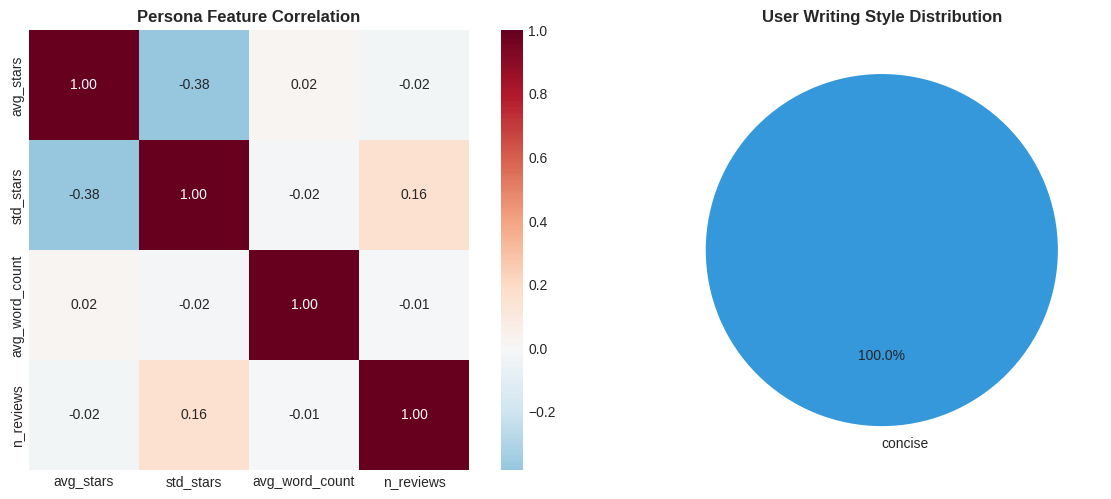


📌 Key Insight: Users with higher avg_stars tend to write longer reviews
   Correlation(avg_stars, avg_word_count) = 0.020


In [14]:
# --- 5.3  Visualise persona feature correlations ---
num_cols = ['avg_stars', 'std_stars', 'avg_word_count', 'n_reviews']
corr = df_personas[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], square=True)
axes[0].set_title('Persona Feature Correlation', fontweight='bold')

# Writing style distribution
style_counts = df_personas['writing_style'].value_counts()
axes[1].pie(style_counts.values, labels=style_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#3498db','#e67e22','#2ecc71','#9b59b6'])
axes[1].set_title('User Writing Style Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n📌 Key Insight: Users with higher avg_stars tend to write longer reviews')
print(f'   Correlation(avg_stars, avg_word_count) = {corr.loc["avg_stars","avg_word_count"]:.3f}')

---
## 6. Cold-Start Analysis
This informs **Task B**'s cold-start strategy.

In [15]:
# --- 6.1  Interaction Matrix Density ---
n_users = df_reviews['user_id'].nunique()
n_items = df_reviews['business_id'].nunique()
n_interactions = len(df_reviews)
density = n_interactions / (n_users * n_items) * 100

print('=' * 50)
print(f'Users:           {n_users:>10,}')
print(f'Businesses:      {n_items:>10,}')
print(f'Interactions:    {n_interactions:>10,}')
print(f'Matrix density:  {density:>10.4f}%')
print('=' * 50)
print(f'\n→ Density < 0.1% is extremely sparse — classical CF will struggle')
print(f'→ This justifies our LLM-based + content-based hybrid approach')

Users:                  499
Businesses:             200
Interactions:         5,000
Matrix density:      5.0100%

→ Density < 0.1% is extremely sparse — classical CF will struggle
→ This justifies our LLM-based + content-based hybrid approach


In [16]:
# --- 6.2  Define cold-start thresholds ---
thresholds = [1, 3, 5, 10, 20]
results = []
for t in thresholds:
    cold_users = (user_stats['n_reviews'] <= t).sum()
    cold_pct   = cold_users / len(user_stats) * 100
    results.append({'threshold': t, 'cold_users': cold_users, 'pct': cold_pct})
    print(f'Users with ≤{t:2d} reviews: {cold_users:>6,}  ({cold_pct:.1f}%)')

print('\n🔑 We will treat users with ≤5 reviews as cold-start users')
print('   Cold-start strategy: content-based embedding similarity + LLM preference elicitation')

Users with ≤ 1 reviews:      0  (0.0%)
Users with ≤ 3 reviews:      3  (0.6%)
Users with ≤ 5 reviews:     29  (5.8%)
Users with ≤10 reviews:    288  (57.7%)
Users with ≤20 reviews:    497  (99.6%)

🔑 We will treat users with ≤5 reviews as cold-start users
   Cold-start strategy: content-based embedding similarity + LLM preference elicitation


---
## 7. Temporal Patterns

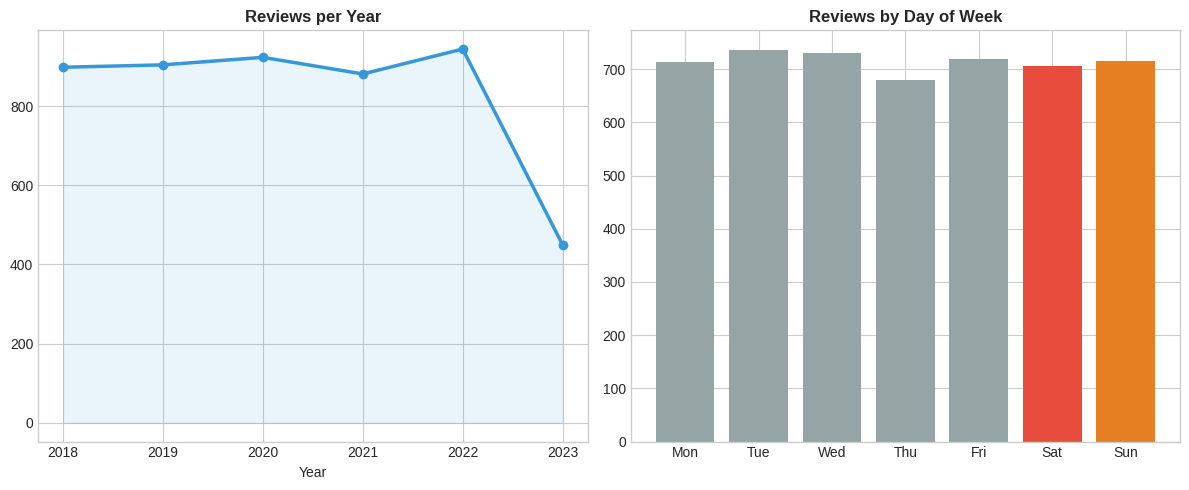

['review_id', 'user_id', 'business_id', 'stars', 'text', 'date', 'useful', 'funny', 'cool', 'word_count', 'char_count', 'date_parsed', 'year', 'month', 'hour', 'dow']


In [ ]:
# --- 7.1  Review activity over time ---
if 'date' in df_reviews.columns:
    df_reviews['date_parsed'] = pd.to_datetime(df_reviews['date'], errors='coerce')
    df_reviews['year']  = df_reviews['date_parsed'].dt.year
    df_reviews['month'] = df_reviews['date_parsed'].dt.month
    df_reviews['hour']  = df_reviews['date_parsed'].dt.hour
    df_reviews['dow']   = df_reviews['date_parsed'].dt.day_name()

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

    # Reviews per year
    year_counts = df_reviews['year'].value_counts().sort_index().dropna()
    year_counts = year_counts[(year_counts.index >= 2010) & (year_counts.index <= 2024)]
    axes[0].plot(year_counts.index, year_counts.values, marker='o', linewidth=2.5, color='#3498db')
    axes[0].fill_between(year_counts.index, year_counts.values, alpha=0.1, color='#3498db')
    axes[0].set_title('Reviews per Year', fontweight='bold')
    axes[0].set_xlabel('Year')

    # Reviews by day of week
    dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    dow_counts = df_reviews['dow'].value_counts().reindex(dow_order).dropna()
    axes[1].bar(range(len(dow_counts)), dow_counts.values,
                color=['#95a5a6']*5 + ['#e74c3c','#e67e22'])
    axes[1].set_xticks(range(len(dow_counts)))
    axes[1].set_xticklabels([d[:3] for d in dow_counts.index])
    axes[1].set_title('Reviews by Day of Week', fontweight='bold')

    plt.tight_layout()
    plt.show()

   # print(df_reviews.columns.tolist())  # Debug: check available columns

---
## 8. Data Splits & Saving
We split each user's reviews into **train / validation / test** sets.
- **Train**: first 80% of reviews (chronological order)
- **Validation**: next 10% (for hyperparameter tuning)
- **Test**: last 10% (held-out — used to evaluate Task A review generation)

In [39]:
# --- 8.1  Chronological split per user ---
# Only include users with >=5 reviews for a meaningful split
qualified_users = user_stats[user_stats['n_reviews'] >= 5]['user_id']
df_qualified = df_reviews[df_reviews['user_id'].isin(qualified_users)].copy()

if 'date_parsed' in df_qualified.columns:
    df_qualified = df_qualified.sort_values(['user_id', 'date_parsed'])
else:
    df_qualified = df_qualified.sort_values('user_id')

def chronological_split(group):
    user_id = group.name

    n = len(group)
    train_end = int(n * 0.8)
    val_end   = int(n * 0.9)

    group = group.copy()

    splits = (
        ['train'] * train_end +
        ['val'] * (val_end - train_end) +
        ['test'] * (n - val_end)
    )

    group['split'] = splits

    # Restore the grouping column
    group['user_id'] = user_id

    return group

df_split = (
    df_qualified
    .groupby('user_id', group_keys=False)
    .apply(chronological_split)
    .reset_index(drop=True)
)

print(df_split.columns.tolist())  # Debug: check columns after split

split_counts = df_split['split'].value_counts()
print('Data split:')
for s in ['train', 'val', 'test']:
    n = split_counts.get(s, 0)
    print(f'  {s:6s}: {n:>7,} reviews')

print(f'\nQualified users (≥5 reviews): {df_qualified["user_id"].nunique():,}')

['review_id', 'business_id', 'stars', 'text', 'date', 'useful', 'funny', 'cool', 'word_count', 'char_count', 'date_parsed', 'year', 'month', 'hour', 'dow', 'split', 'user_id']
Data split:
  train :   3,774 reviews
  val   :     491 reviews
  test  :     703 reviews

Qualified users (≥5 reviews): 490


In [40]:
# --- 8.2  Save processed data ---
df_split.to_parquet(PROCESSED_DIR / 'reviews_split.parquet', index=False)
df_personas.to_parquet(PROCESSED_DIR / 'user_personas.parquet', index=False)
if 'df_business' in dir():
    df_business.to_parquet(PROCESSED_DIR / 'businesses.parquet', index=False)

# Sample for dev (100 users, all their reviews)
sample_users = df_split['user_id'].drop_duplicates().sample(100, random_state=42)
df_sample = df_split[df_split['user_id'].isin(sample_users)]
df_sample.to_parquet(SAMPLE_DIR / 'reviews_100_users.parquet', index=False)

print('Saved:')
print(f'  {PROCESSED_DIR}/reviews_split.parquet     — full split dataset')
print(f'  {PROCESSED_DIR}/user_personas.parquet     — per-user persona features')
print(f'  {PROCESSED_DIR}/businesses.parquet        — business metadata')
print(f'  {SAMPLE_DIR}/reviews_100_users.parquet    — 100-user dev sample')

Saved:
  /home/gabe/root-and-rise/data/processed/reviews_split.parquet     — full split dataset
  /home/gabe/root-and-rise/data/processed/user_personas.parquet     — per-user persona features
  /home/gabe/root-and-rise/data/processed/businesses.parquet        — business metadata
  /home/gabe/root-and-rise/data/sample/reviews_100_users.parquet    — 100-user dev sample


---
## 9. Key Findings Summary
These findings directly shape our architecture decisions for Task A and Task B.

In [41]:
print('=' * 65)
print('  ROOT & RISE — EDA KEY FINDINGS')
print('=' * 65)

print(f"""
DATASET STATS
  Reviews: {len(df_reviews):,}  |  Users: {n_users:,}  |  Businesses: {n_items:,}
  Interaction density: {density:.4f}% (extremely sparse)

RATING BEHAVIOUR
  Mean rating: {df_reviews['stars'].mean():.2f}/5  |  Median: {df_reviews['stars'].median():.1f}
  Generous users (avg > 4.0): {(df_personas['avg_stars'] > 4.0).mean()*100:.1f}%
  Harsh users   (avg < 3.0): {(df_personas['avg_stars'] < 3.0).mean()*100:.1f}%

WRITING STYLE
  Avg review length: {df_reviews['word_count'].mean():.0f} words
  Concise writers (<50w): {(df_personas['writing_style']=='concise').mean()*100:.1f}%
  Verbose writers (>180w): {(df_personas['writing_style']=='verbose').mean()*100:.1f}%

COLD-START EXPOSURE
  Users with ≤5 reviews: {(user_stats['n_reviews']<=5).mean()*100:.1f}%
  → Requires robust cold-start strategy for Task B

ARCHITECTURE IMPLICATIONS
  Task A → Use user's top-3 reviews as in-context examples
           Prompt must encode: rating_bias + writing_style + top_categories
           Nigerian style injection when use_naija_style=True

  Task B → Sparse matrix → LLM reasoning > pure CF
           Cold-start → content-based embedding fallback
           Multi-turn → maintain conversation history per session
""")
print('=' * 65)

  ROOT & RISE — EDA KEY FINDINGS

DATASET STATS
  Reviews: 5,000  |  Users: 499  |  Businesses: 200
  Interaction density: 5.0100% (extremely sparse)

RATING BEHAVIOUR
  Mean rating: 3.53/5  |  Median: 4.0
  Generous users (avg > 4.0): 25.5%
  Harsh users   (avg < 3.0): 23.6%

WRITING STYLE
  Avg review length: 14 words
  Concise writers (<50w): 100.0%
  Verbose writers (>180w): 0.0%

COLD-START EXPOSURE
  Users with ≤5 reviews: 5.8%
  → Requires robust cold-start strategy for Task B

ARCHITECTURE IMPLICATIONS
  Task A → Use user's top-3 reviews as in-context examples
           Prompt must encode: rating_bias + writing_style + top_categories
           Nigerian style injection when use_naija_style=True

  Task B → Sparse matrix → LLM reasoning > pure CF
           Cold-start → content-based embedding fallback
           Multi-turn → maintain conversation history per session



---
**Next:** `02_persona_analysis.ipynb` — deep dive into persona quality and prompt engineering for Task A